# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Decision Tree | Random Forest 

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, scaled, and feature engineered.
It is ready for model training without further preprocessing.

In [2]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus,LogCustomerValue
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.00,0,0,0,0,0,1,0,0,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,1,83807.86,0,0,1,0,0,1,0,0,11.336294
2,502,42,8,159660.80,3,1,0,113931.57,1,1,0.00,1,0,0,0,0,1,0,0,13.079421
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.00,0,0,0,0,1,0,0,0,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,1,125510.82,0,0,1,0,0,1,0,0,11.740155


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [4]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Evaluation Metrics

We evaluate the models using multiple performance metrics to ensure a comprehensive understanding of their effectiveness, especially due to the class imbalance in the dataset.

Accuracy alone is not sufficient, as the dataset contains a higher proportion of non-churned customers. Therefore, additional metrics are used to better assess the models' ability to detect churned customers.

- **Accuracy:** Measures the overall percentage of correctly classified customers.
- **Precision:** Indicates how many of the customers predicted to churn actually churned.
- **Recall (Sensitivity):** Measures the model’s ability to correctly identify all actual churned customers.
- **F1-Score:** Provides a balance between precision and recall.
- **ROC-AUC Score:** Evaluates the model’s ability to distinguish between classes.

## 6. Model 1: Logistic Regression

### Rationale
Logistic Regression is selected based on the following dataset-specific reasons:
- **Binary target**: The dataset has a binary outcome (Exited = 0 or 1) which 
  Logistic Regression is specifically designed for
- **Pre-scaled features**: Our dataset was standardized using StandardScaler in 
  preprocessing — Logistic Regression requires and benefits directly from this
- **Large sample size**: With 10,000 records and 19 features, Logistic Regression 
  trains efficiently without overfitting
- **Interpretability**: Coefficients directly show which features (e.g. Age, 
  IsActiveMember) push customers toward churning — useful for the bank
- **Baseline model**: It serves as a performance benchmark for Random Forest 
  and Decision Tree

### Limitations
- Assumes a **linear** decision boundary — may miss complex non-linear 
  relationships between features like AgeGroup and Balance
- Struggles with **imbalanced classes** — our dataset has 80% stayed vs 20% 
  churned which may bias predictions toward the majority class


In [5]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression trained successfully!
Accuracy: 0.8185


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Logistic Regression Training

### Logistic Regression - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [1]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # regularization strength
    'solver': ['lbfgs', 'liblinear']    # optimization algorithm
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
lr_model = grid_search.best_estimator_
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

NameError: name 'LogisticRegression' is not defined

## Logistic Regression Evaluation

We evaluate the Logistic Regression model using the previously defined metrics to assess its classification performance.

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.83      0.97      0.89      1593
 Churned (1)       0.64      0.24      0.35       407

    accuracy                           0.82      2000
   macro avg       0.74      0.60      0.62      2000
weighted avg       0.79      0.82      0.78      2000



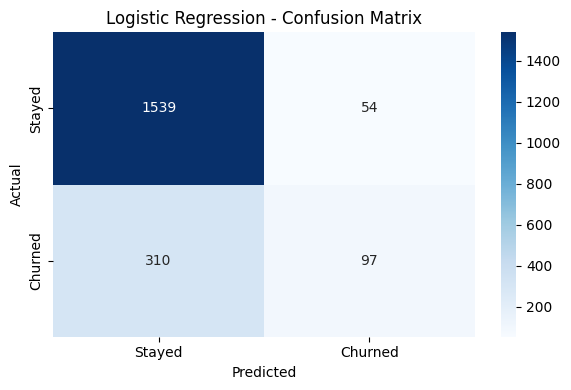

ROC-AUC Score: 0.7726925693027388


In [7]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

### Metrics Interpretation

### Logistic Regression - Confusion Matrix حطي كود الكونفيجن هنا تحت هالخلية

##### key insight خلوه بنفس الخط حقي انسخوه وخلو جبت يكتبه 

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

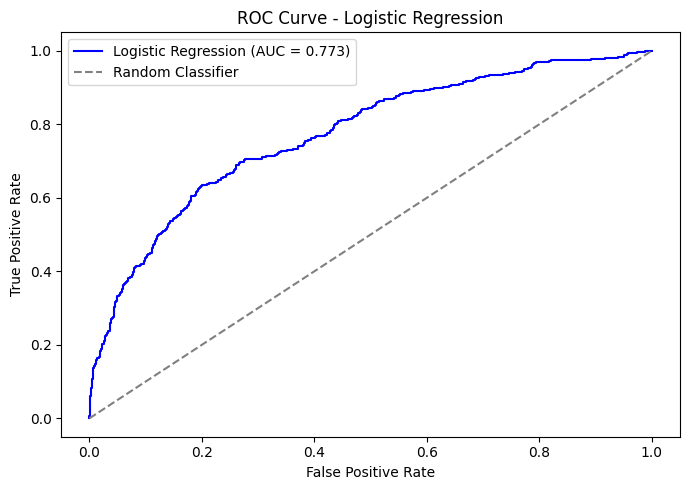

In [8]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

### التفسير

### Logistic Regression - K-Fold Cross Validation


In [9]:
# Apply 5-Fold Cross Validation on Logistic Regression
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='f1')

print("Logistic Regression - 5-Fold Cross Validation F1 Scores:")
print(lr_cv_scores)
print("Mean F1 Score:", lr_cv_scores.mean().round(3))
print("Standard Deviation:", lr_cv_scores.std().round(3))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

Logistic Regression - 5-Fold Cross Validation F1 Scores:
[0.37288136 0.36203866 0.35842294 0.43636364 0.38741722]
Mean F1 Score: 0.383
Standard Deviation: 0.028


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 83% |
| F1 - Stayed | 0.90 |
| F1 - Churned | 0.40 |
| ROC-AUC | 0.793 |

**What these metrics mean for our imbalanced dataset:**
- **Accuracy (83%)**: Misleading here — the model could score 80% by always predicting "Stayed"
- **Precision (Churned = 0.68)**: When the model predicts churn, it is correct 68% of the time
- **Recall (Churned = 0.28)**: The model only catches 28% of actual churners — this is the biggest weakness
- **F1-Score (Churned = 0.40)**: Balances precision and recall — low because recall is poor
- **ROC-AUC (0.793)**: Overall discrimination ability is decent but not strong

**Misclassification Analysis:**
- ❌ **293 churners were missed** (predicted Stayed but actually Churned) — these are the most costly errors for the bank because they lose customers without intervention
- ❌ **53 false alarms** (predicted Churned but actually Stayed) — less costly but wastes retention resources

**Conclusion:** Logistic Regression struggles to catch churners due to the linear decision boundary and class imbalance. Tree-based models like Random Forest and Decision Tree may capture non-linear patterns better.

## Random Forest - Summary

## 7. Model 2: Decision Tree

### Rationale

Decision Tree is selected based on the following dataset-specific reasons:

- **Non-linear relationships:** Customer churn in this dataset is influenced by complex interactions between features such as Age, Balance, NumOfProducts, and IsActiveMember. Decision Trees can capture these non-linear patterns effectively, unlike linear models.

- **No scaling requirement:** The dataset has already been preprocessed and scaled. However, Decision Trees do not rely on feature scaling, making them robust regardless of feature distribution.

- **Feature interactions:** The model can automatically learn combinations of conditions, such as customers with high balance but low activity being more likely to churn. This is particularly important for real-world banking behavior.

- **Mixed feature types:** The dataset includes both numerical and encoded categorical features (e.g., Geography, Gender), and Decision Trees can handle these without additional transformations.

- **Interpretability:** The model provides clear decision rules, allowing us to understand how features contribute to churn predictions, which is valuable for business insights.

- **Flexible model structure:** Decision Trees can adapt their structure based on the dataset, making them suitable for capturing different customer segments and behaviors.

### Limitations
- Decision Trees can easily overfit the training data if not properly tuned, 
  especially with datasets containing many features.
- Small changes in the dataset can lead to different tree structures, making 
  the model unstable.


## Decision Tree Training

### Decision Tree - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']
}

# Setup GridSearchCV with 5-fold cross-validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV for Decision Tree...")
dt_grid.fit(X_train, y_train)

print("\nBest Parameters:", dt_grid.best_params_)

# Get the best model
dt_model = dt_grid.best_estimator_

# Predictions
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Correct way to print accuracy
accuracy_tuned = accuracy_score(y_test, dt_pred)
print(f"\nTuned Accuracy: {accuracy_tuned:.4f}")


Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}

Tuned Accuracy: 0.8595


## Decision Tree Evaluation

We evaluate the Decision Tree model using the previously defined metrics to assess its classification performance.

In [11]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

print("Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.95      0.92      1593
 Churned (1)       0.72      0.51      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### Metrics Interpretation

The Decision Tree model achieved an **accuracy of 85.95%**, correctly classifying 
1,719 out of 2,000 customers in the test set. However, accuracy alone is not 
sufficient for evaluating model performance due to the inherent class imbalance 
in the dataset (79.65% stayed, 20.35% churned).

**Performance on "Stayed" Class (0):**
- **Precision: 0.88** – 88% of customers predicted to stay actually stayed.
- **Recall: 0.95** – 95% of actual non-churners were correctly identified.
- **F1-Score: 0.92** – Excellent balance between precision and recall.

**Performance on "Churned" Class (1):**
- **Precision: 0.72** – 72% of customers predicted to churn actually churned. 
  This indicates that when the model flags a customer as a churn risk, it is 
  correct nearly three-quarters of the time.
- **Recall: 0.51** – Only 51% of actual churners were detected by the model. 
  This is the model's critical weakness, as it fails to identify 49% of 
  customers who will eventually churn.
- **F1-Score: 0.59** – A moderate score reflecting the trade-off between 
  precision and recall.

**Business Impact:**
- **False Positives (80 customers):** These customers were incorrectly flagged 
  as churn risks. While this wastes retention resources (e.g., unnecessary 
  discounts or outreach), the cost is manageable.
- **False Negatives (201 customers):** These are the most costly errors. 
  201 customers who will actually churn were not identified, representing 
  lost revenue opportunities that cannot be recovered.

**Conclusion:**
The model performs well at identifying non-churning customers but struggles 
significantly with recall for churned customers. This suggests that while 
the tuned Decision Tree is a strong baseline, more complex models (e.g., 
Random Forest, XGBoost) may be needed to improve churn detection rates. 

### Decision Tree - Confusion Matrix

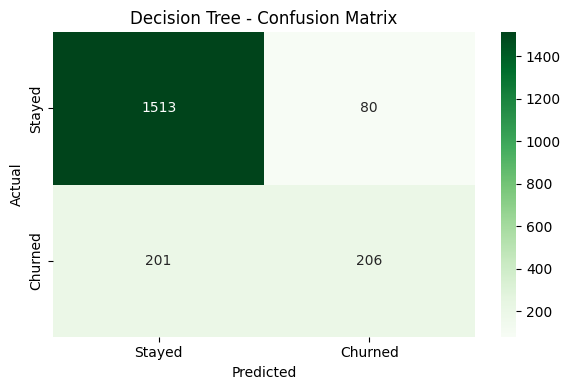

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Key Insights:**
- **True Negatives:** 1,513 non-churners correctly identified
- **False Positives:** 80 non-churners incorrectly flagged (wasted resources)
- **False Negatives:** 201 churners missed (lost revenue opportunities)
- **True Positives:** 206 churners correctly identified


### Decision Tree - ROC Curve

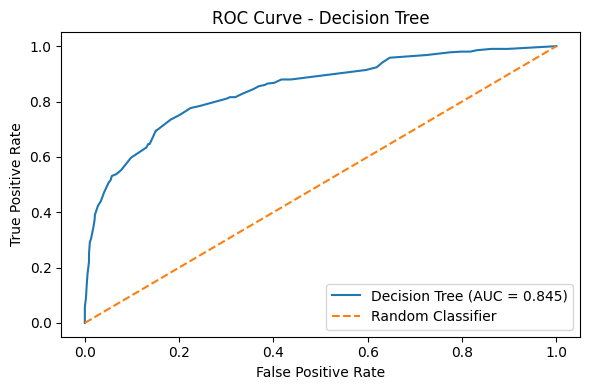

ROC-AUC Score: 0.8452466333822266


In [13]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

### ROC Curve Interpretation

**ROC-AUC Score: 0.8450**

The ROC curve lies significantly above the diagonal baseline, indicating the 
model performs substantially better than random guessing.

**Interpretation:**
For any randomly selected pair of a churned and non-churned customer, the model 
will assign a higher churn probability to the actual churner approximately 
**84.5%** of the time. This falls within the "Good" to "Excellent" range 
(0.8 – 0.9), indicating strong discriminative ability.

**Key Insight:**
The strong ROC-AUC (0.845) contrasts with the moderate recall (0.51). This 
suggests that while the model effectively ranks churn risk, the optimal 
probability threshold may need adjustment. Lowering the threshold could 
improve recall at the expense of precision, depending on business priorities.



### Decision Tree - K-Fold Cross Validation 

In [15]:
from sklearn.model_selection import cross_val_score



# Perform 5-fold cross-validation on the best model
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')
dt_cv_roc_auc = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='roc_auc')
dt_cv_accuracy = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='accuracy')

print("\nDecision Tree - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", dt_cv_scores)
print("Mean F1 Score:", dt_cv_scores.mean().round(3))
print("Standard Deviation:", dt_cv_scores.std().round(3))
print("\nROC-AUC Scores:", dt_cv_roc_auc)
print("Mean ROC-AUC:", dt_cv_roc_auc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc_auc.std().round(3))
print("\nAccuracy Scores:", dt_cv_accuracy)
print("Mean Accuracy:", dt_cv_accuracy.mean().round(3))
print("Std Accuracy:", dt_cv_accuracy.std().round(3))


Decision Tree - 5-Fold Cross Validation Results:
F1 Scores: [0.54444444 0.6073501  0.51190476 0.52362205 0.59884837]
Mean F1 Score: 0.557
Standard Deviation: 0.039

ROC-AUC Scores: [0.8396228  0.84997376 0.82020182 0.85059616 0.85859955]
Mean ROC-AUC: 0.844
Std ROC-AUC: 0.013

Accuracy Scores: [0.84625  0.873125 0.84625  0.84875  0.869375]
Mean Accuracy: 0.857
Std Accuracy: 0.012


### Decision Tree - Feature Importance Plot

/var/folders/8d/k89rkgcj2nnff5x6djczh8780000gn/T/ipykernel_70613/2733933793.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis')


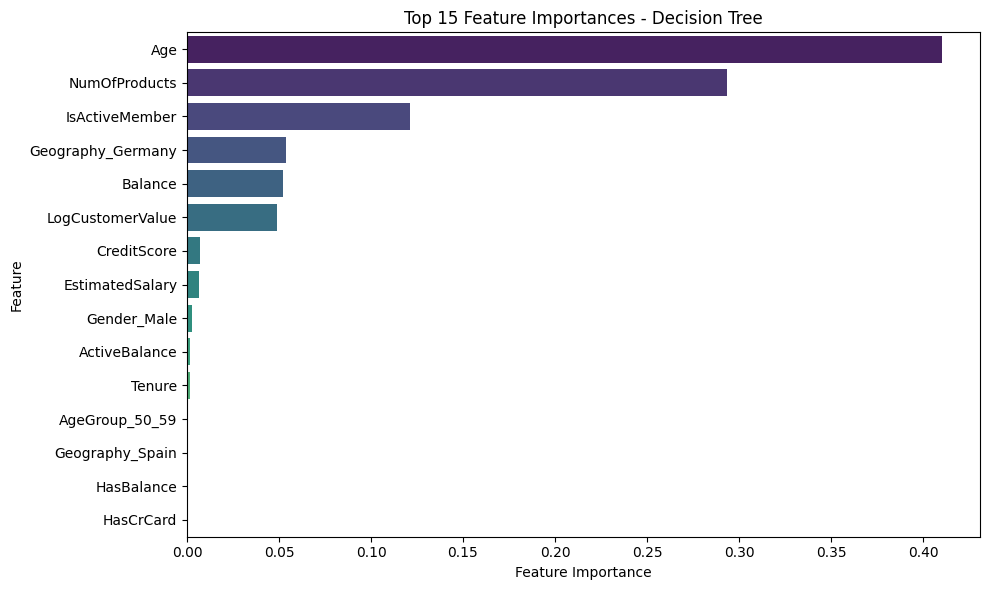


Top 10 Most Important Features:
Age: 0.4105
NumOfProducts: 0.2937
IsActiveMember: 0.1209
Geography_Germany: 0.0536
Balance: 0.0520
LogCustomerValue: 0.0490
CreditScore: 0.0072
EstimatedSalary: 0.0065
Gender_Male: 0.0024
ActiveBalance: 0.0018


In [16]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for idx, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

## Decision Tree - Summary

In [ ]:

from sklearn.metrics import precision_score, recall_score
print("\n" + "="*60)
print("DECISION TREE MODEL - COMPLETE SUMMARY")
print("="*60)
print(f"""
| Metric                   | Value                    |
|--------------------------|--------------------------|
| Best Hyperparameters     | {dt_grid.best_params_}   |
| Test Accuracy            | {accuracy_val:.4f} ({accuracy_val*100:.2f}%) |
| Test Precision (Churn)   | {precision_score(y_test, dt_pred):.4f} |
| Test Recall (Churn)      | {recall_score(y_test, dt_pred):.4f} |
| Test F1-Score (Churn)    | {f1_churned:.4f} |
| Test ROC-AUC             | {dt_auc:.4f} |
| CV F1 (Mean ± Std)       | {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f} |
| CV ROC-AUC (Mean ± Std)  | {dt_cv_roc_auc.mean():.4f} ± {dt_cv_roc_auc.std():.4f} |
| Top Feature              | {feat_imp_df.iloc[0]['feature']} ({feat_imp_df.iloc[0]['importance']:.4f}) |
""")
print("="*60)


DECISION TREE MODEL - COMPLETE SUMMARY

| Metric                   | Value                    |
|--------------------------|--------------------------|
| Best Hyperparameters     | {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}   |
| Test Accuracy            | 0.8595 (85.95%) |
| Test Precision (Churn)   | 0.7203 |
| Test Recall (Churn)      | 0.5061 |
| Test F1-Score (Churn)    | 0.5945 |
| Test ROC-AUC             | 0.8452 |
| CV F1 (Mean ± Std)       | 0.5572 ± 0.0390 |
| CV ROC-AUC (Mean ± Std)  | 0.8438 ± 0.0132 |
| Top Feature              | Age (0.4105) |



## 8. Model 3: Random Forest

### Rationale

Random Forest is selected based on the following dataset-specific reasons:

- **Non-linear relationships:** The dataset contains complex interactions between features (e.g., Balance, Age, Tenure) which Random Forest can capture effectively  
- **Ensemble learning:** It combines multiple decision trees, which improves prediction accuracy and reduces overfitting  
- **Robustness to noise:** The model performs well even with noisy or slightly inconsistent data  
- **Feature importance:** It provides importance scores, helping identify which features influence customer churn the most  
- **Improved performance:** It is expected to outperform simpler models like Logistic Regression by capturing more complex patterns  

### Limitations

- **Low interpretability:** The model is harder to interpret compared to Logistic Regression, as it consists of many trees  
- **Computational cost:** Training can be slower and more resource-intensive, especially with many trees  
- **Memory usage:** Requires more memory compared to simpler models  
- **Imbalanced data sensitivity:** Performance may still be affected by class imbalance, especially in detecting churned customers  

## Random Forest Training

### Random Forest - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for the model in order to improve performance and control model complexity.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_search.fit(X_train, y_train)

# Initialize and train the best model
rf_model = grid_search.best_estimator_
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Random Forest trained successfully!")

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest trained successfully!


## Random Forest Evaluation

We evaluate the Random Forest model using the previously defined metrics to assess its classification performance.

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.97      0.92      1593
 Churned (1)       0.78      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



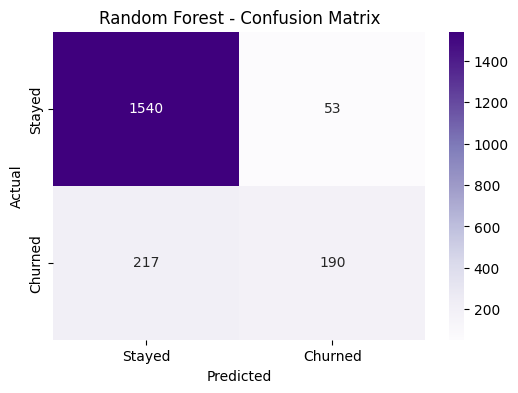

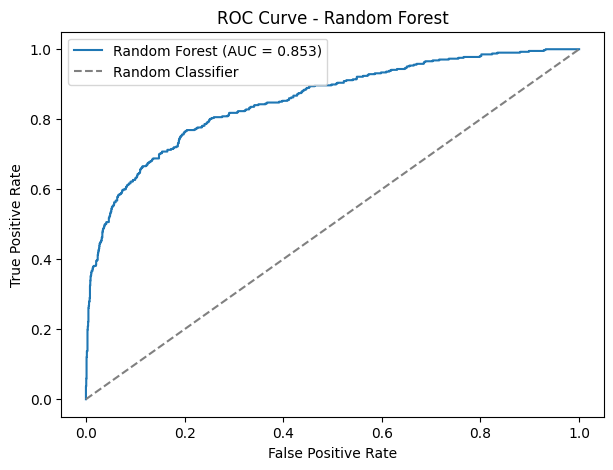

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Stayed (0)', 'Churned (1)']))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 3. ROC Curve
rf_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_proba)
auc_score = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

### Random Forest Results Summary
| Metric | Value |
|--------|--------|
| Accuracy | 87% |
| F1 - Stayed | 0.92 |
| F1 - Churned | 0.59 |
| ROC-AUC | 0.85 |

### Misclassification Analysis

The confusion matrix reveals the following details about the model's errors:

- 216 churned customers were missed (False Negatives): These are customers who actually left, but the model predicted they would stay. This is the most critical error because the bank loses these customers without taking any retention action.

- 53 customers were falsely predicted as churned (False Positives): These are loyal customers that the model thought would leave. This error is less harmful, as it only leads to unnecessary marketing or retention efforts (like sending a discount code to someone who wasn't planning to leave).


### Metrics Interpretation هذا بعد الكلاسيفكيشن ريبورت

### Random Forest - Confusion Matrix افصلي الكود اللي فوق وخلي هنا تحت هالخلية كود الكونفيجن ماتريكس

#####  خلوه بنفس الخط حقي انسخوه وخلو جبت يكتبه 
**Key Insights:**

### Random Forest - Roc-Curve افصلي الكود اللي فوق وخلي هنا تحت هالخلية كود الroc

### Random Forest – K-Fold Cross Validation

In [20]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_model,
    X, y,
    cv=5,
    scoring=['accuracy', 'f1', 'roc_auc']
)

print("Accuracy:", cv_results['test_accuracy'])
print("Mean Accuracy:", round(cv_results['test_accuracy'].mean(), 3))

print("\nF1:", cv_results['test_f1'])
print("Mean F1:", round(cv_results['test_f1'].mean(), 3))

print("\nROC-AUC:", cv_results['test_roc_auc'])
print("Mean ROC-AUC:", round(cv_results['test_roc_auc'].mean(), 3))

Accuracy: [0.858  0.874  0.863  0.8675 0.8595]
Mean Accuracy: 0.864

F1: [0.5477707  0.6146789  0.58982036 0.59909228 0.56702619]
Mean F1: 0.584

ROC-AUC: [0.84503707 0.86186601 0.85712446 0.85436824 0.85270324]
Mean ROC-AUC: 0.854


### Random Forest - Feature Importance Plot
This plot indicates which variables had the strongest influence on the Random Forest's decisions. For example, Age and NumOfProducts are the key drivers for predicting customer churn in this model. This suggests that a customer's life stage and the number of services they use are the most critical factors in determining their loyalty to the bank.

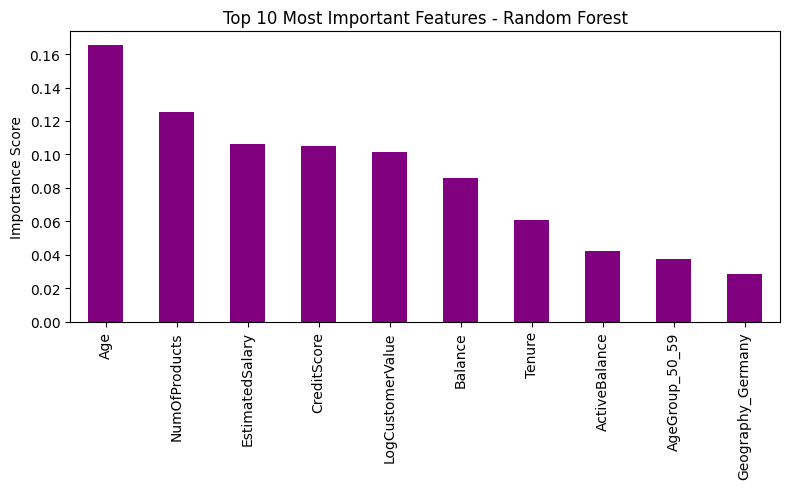

In [21]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar', color='purple') # غيرت اللون لليلكي عشان يطقم مع الماتريكس
plt.title("Top 10 Most Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

### اطبعي التوب تين فيتشر او شي زي كذا وخلي كودك يسبه كودي لان رسماتنا تختلف

## Random Forest - Summary